# Kickstarters Analysis
---

Group Name

Team members:
- Aqeela Ali
- Zahraa Alekri

## Introduction 
__Introduction to the topic__ 

    Kickstarter is basically the go-to place for creators to get their ideas funded by the public. In this project, we’re looking into a huge dataset of campaigns to see what’s actually happening behind the scenes. We want to go beyond just looking at numbers; we want to understand why some projects blast past their goals while others struggle to get any traction. By analyzing things like categories and funding targets, we hope to find some clear patterns that can help future creators plan their campaigns better.

---

## Problem Statement

    A lot of people have great ideas but struggle to get their projects funded on Kickstarter because they don’t really understand what makes a campaign succeed. Many creators set goals that are too high, choose categories that aren’t popular, or launch at the wrong time; often relying on guesswork instead of data. This project will explore Kickstarter data to uncover what actually drives success, like the best goal range, category, timing, and location so creators can make smarter decisions and increase their chances of getting funded.

## Objectives:
__Questions that will guide the analysis to solve the problem__

    We want to understand what really drives success on kickstarters. To do that, our analysis will focus on a few key questions:

1- Which categories (like tech, art, or film) tend to succeed the most? 

2- Does the goal amount influence wheather a campaign succeeds or fails?

3- How much do people usually pledge, and does that change depending on the project category?

4- Are there certain times of the year when campaigns do better?

5- Based on what we find, what advice can we give to future creators to help them launch more successful campaigns?

---

## Exploratory Data Analysis (EDA):

## Data Dictionary

| Field       | Description                                                       |
|-------------|-------------------------------------------------------------------|
| Category    | Project category                                                  |
| Subcategory | Project subcategory                                               |
| Country     | Country the project is from                                       |
| Launched    | Date the project was launched                                     |
| Deadline    | Deadline date for crowdfunding                                    |
| Goal        | Amount of money the creator needs to complete the project (USD)   |
| Pledged     | Amount of money pledged by the crowd (USD)                        |
| Backers     | Number of backers                                                 |
| State       | Current condition the project is in (as of 2018-01-02)            |
| Launch_Year | Year the project was launched                                     |
| Launch_Month| Month the project was launched (1–12)                             |
| Launch_Day  | Day of the month the project was launched                         |
| Launch_Hour | Hour of the day the project was launched (0–23)                   |
| Project_Duration| Total campaign length in days (Deadline – Launch Date)        |
| Pledged_Ratio| Ratio of pledged amount to Goal                                  |

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/kickstarter_projects.csv')

In [3]:
df.head()

,ID,Name,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


In [4]:
df.shape

(374853, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374853 entries, 0 to 374852
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   ID           374853 non-null  int64
 1   Name         374853 non-null  str  
 2   Category     374853 non-null  str  
 3   Subcategory  374853 non-null  str  
 4   Country      374853 non-null  str  
 5   Launched     374853 non-null  str  
 6   Deadline     374853 non-null  str  
 7   Goal         374853 non-null  int64
 8   Pledged      374853 non-null  int64
 9   Backers      374853 non-null  int64
 10  State        374853 non-null  str  
dtypes: int64(4), str(7)
memory usage: 31.5 MB


The data is structurally sound, but the date columns need formatting in the next step to allow for time-based analysis.

In [6]:
df.isnull().sum()

ID             0
Name           0
Category       0
Subcategory    0
Country        0
Launched       0
Deadline       0
Goal           0
Pledged        0
Backers        0
State          0
dtype: int64

No Missing Values: The dataset is complete with 0 null values across all columns.

In [7]:
df.describe()

,ID,Goal,Pledged,Backers
count,3.748530e+05,3.748530e+05,3.748530e+05,374853.000000
mean,1.074656e+09,4.586378e+04,9.121073e+03,106.690359
std,6.191377e+08,1.158778e+06,9.132054e+04,911.718520
min,5.971000e+03,0.000000e+00,0.000000e+00,0.000000
25%,5.380728e+08,2.000000e+03,3.100000e+01,2.000000
50%,1.075300e+09,5.500000e+03,6.250000e+02,12.000000
75%,1.610149e+09,1.600000e+04,4.051000e+03,57.000000
max,2.147476e+09,1.663614e+08,2.033899e+07,219382.000000


Observations: 

Outliers in Goals: There is a huge gap between the average goal ($49k) and the maximum goal ($100M). This suggests that some projects set unrealistic targets.

Success Metrics: On average, projects get about 106 backers, but the standard deviation is very high, meaning there's a big difference between "viral" projects and those that get no support.

In [8]:
df['State'].unique()

<StringArray>
['Failed', 'Successful', 'Canceled', 'Suspended', 'Live']
Length: 5, dtype: str

In [9]:
df['State'].value_counts()

State
Failed        197611
Successful    133851
Canceled       38751
Live            2798
Suspended       1842
Name: count, dtype: int64

Target Variable (State): Projects are categorized into different states (Successful, Failed, etc.). We will focus our analysis on the completed projects to understand success factors.

In [10]:
df['Category'].unique()

<StringArray>
[     'Fashion', 'Film & Video',          'Art',   'Technology',
   'Journalism',   'Publishing',      'Theater',        'Music',
  'Photography',        'Games',       'Design',         'Food',
       'Crafts',       'Comics',        'Dance']
Length: 15, dtype: str

In [11]:
df['Category'].value_counts()

Category
Film & Video    62694
Music           49529
Publishing      39378
Games           35225
Technology      32562
Design          30065
Art             28151
Food            24599
Fashion         22812
Theater         10911
Comics          10819
Photography     10778
Crafts           8809
Journalism       4754
Dance            3767
Name: count, dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df[df['Goal']<= 0]

,ID,Name,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State
1085,620302213,LOVELAND Round 6: A Force More Powerful,Art,Conceptual Art,United States,2009-11-25 07:54:49,2009-12-04,0,100,6,Successful
33831,688564643,"Word-of-mouth publishing: get ""Corruptions"" ou...",Publishing,Fiction,United States,2011-11-07 16:46:52,2011-12-13,0,0,0,Canceled
40294,9572984,Nana,Film & Video,Shorts,United States,2012-01-25 07:23:19,2012-03-16,0,0,0,Failed
316197,1379346088,Bug's Big Adventure: Mexico Edition,Art,Art,Mexico,2016-11-11 16:30:00,2016-11-12,0,16,7,Successful


In [14]:
df['Country'].value_counts()

Country
United States     292618
United Kingdom     33671
Canada             14756
Australia           7839
Germany             4171
France              2939
Italy               2878
Netherlands         2868
Spain               2276
Sweden              1757
Mexico              1752
New Zealand         1447
Denmark             1113
Ireland              811
Switzerland          760
Norway               708
Hong Kong            618
Belgium              617
Austria              597
Singapore            555
Luxembourg            62
Japan                 40
Name: count, dtype: int64

### Data Handling: 
__Cleaning, transforming, and combining data__

In [15]:
#convert date columns to datetime
df['Launched'] = pd.to_datetime(df['Launched'])
df['Deadline'] = pd.to_datetime(df['Deadline'])

In [16]:
#extract date and time
df['Launch_Date'] = df['Launched'].dt.date
df['Launch_Time'] = df['Launched'].dt.time
df['Launch_Year'] = df['Launched'].dt.year
df['Launch_Month'] = df['Launched'].dt.month
df['Launch_Day'] = df['Launched'].dt.day
df['Launch_Hour'] = df['Launched'].dt.hour

In [17]:
#calculate project duration in days
df['Project_Duration'] = (df['Deadline'] - df['Launched']).dt.days

In [18]:
unrealistic_goals = df[df['Goal'] > 1000000]
print(f"Number of projects with goals that are more than 1M: {len(unrealistic_goals)}")

Number of projects with goals that are more than 1M: 1083


In [19]:
df = df[df['State'].isin(['Successful', 'Failed'])].copy()

In [20]:
unrealistic_goals = df[df['Goal'] > 1000000]
print(f"Number of projects with goals that are more than 1M: {len(unrealistic_goals)}")

Number of projects with goals that are more than 1M: 838


In [21]:
#remove projects with invalid durations
df = df[df['Project_Duration'] > 0]

In [22]:
df = df.drop(columns=['ID', 'Name'])

In [23]:
#creating a new feature to calculate the ratio of pledged amount to goal
df['Pledged_Ratio'] = df['Pledged'] / df['Goal']

In [24]:
df['state_numeric'] = df['State'].map({'Successful': 1, 'Failed': 0})

In [25]:
df.head()

,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State,Launch_Date,Launch_Time,Launch_Year,Launch_Month,Launch_Day,Launch_Hour,Project_Duration,Pledged_Ratio,state_numeric
0,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed,2009-04-21,21:02:48,2009,4,21,21,39,0.625000,0
1,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed,2009-04-23,00:07:53,2009,4,23,0,87,0.000275,0
2,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful,2009-04-24,21:52:03,2009,4,24,21,8,1.750000,1
3,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful,2009-04-25,17:36:21,2009,4,25,17,79,1.464646,1
4,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed,2009-04-27,14:10:39,2009,4,27,14,28,0.203684,0


In [26]:
df.to_csv('data/cleaned_kickstarter.csv', index=False)

### Analysis: 
__Answering the objectives through data analysis__



In [21]:
import seaborn as sns

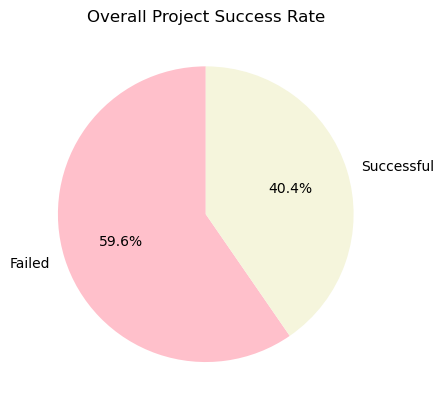

In [69]:
df['State'].value_counts().plot(kind='pie',autopct='%1.1f%%', colors=['pink', 'beige'],startangle=90)
plt.title('Overall Project Success Rate')
plt.ylabel('')
plt.show()

We can see that around 40% of projects succeed, while 60% fail. This shows that Kickstarter is a competitive platform and success is not guaranteed.

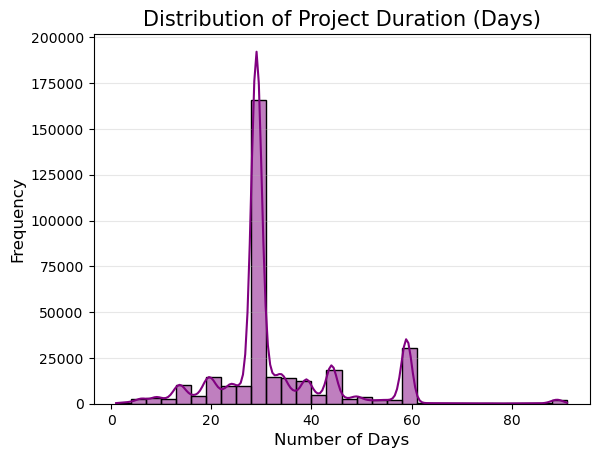

In [72]:
sns.histplot(df['Project_Duration'], bins=30, kde=True, color='purple')
plt.title('Distribution of Project Duration (Days)', fontsize=15)
plt.xlabel('Number of Days', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

Project Duration: Most projects tend to cluster around the 30-day mark. This suggests that 30 days is the standard or "ideal" duration recommended by Kickstarter or chosen by creators.

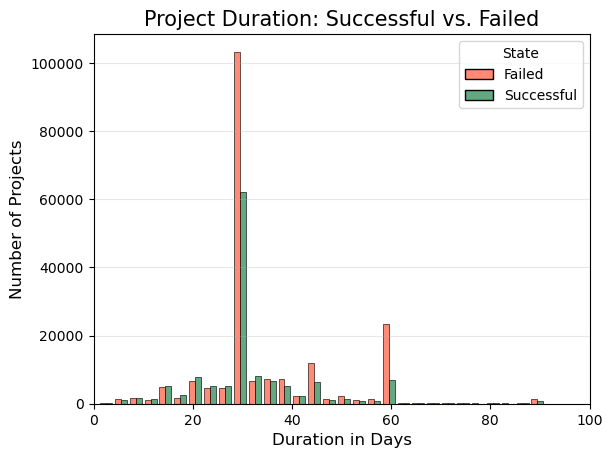

In [88]:
sns.histplot(data=df, x='Project_Duration', hue='State', bins=30, palette=['#FF6347', '#2E8B57'], multiple='dodge', shrink=0.8)
plt.title('Project Duration: Successful vs. Failed', fontsize=15)
plt.xlabel('Duration in Days', fontsize=12)
plt.ylabel('Number of Projects', fontsize=12)
plt.xlim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.show()

Observations: Project Duration vs. Success

-The 30-Day Peak: There is a significant spike in the number of projects around the 30-day mark. This indicates that 30 days is the most popular duration chosen by creators, likely due to Kickstarter’s recommendations.

-Success Concentration: Successful projects (green) are heavily concentrated in the 20 to 40-day range. This suggests that mid-length campaigns are more effective at maintaining momentum and reaching their goals.

-The "Long-Tail" Failure: As the duration exceeds 60 days, the proportion of failed projects (red) increases compared to successful ones.

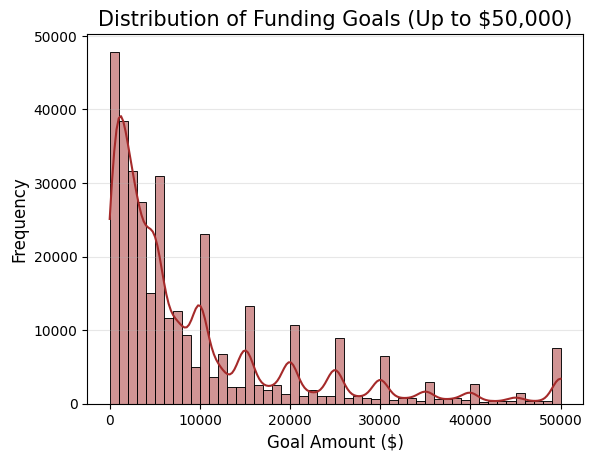

In [22]:
#we filtered the goals to $50k to avoid the distortion caused by extreme outliers (like the $100M projects)
sns.histplot(df[df['Goal'] <= 50000]['Goal'], bins=50, kde=True, color='brown') 
plt.title('Distribution of Funding Goals (Up to $50,000)', fontsize=15)
plt.xlabel('Goal Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

Funding Goals: The distribution is "Right-Skewed," meaning most projects set relatively small goals (under $10,000), while only a few projects ask for very large amounts.

In [24]:
cols_to_analyze = ['Goal', 'Pledged', 'Backers', 'Project_Duration', 'state_numeric']
corr_matrix = df[cols_to_analyze].corr()
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                      Goal   Pledged   Backers  Project_Duration  \
Goal              1.000000  0.005566  0.004476          0.022367   
Pledged           0.005566  1.000000  0.753449          0.006934   
Backers           0.004476  0.753449  1.000000         -0.001685   
Project_Duration  0.022367  0.006934 -0.001685          1.000000   
state_numeric    -0.023732  0.108359  0.125848         -0.116466   

                  state_numeric  
Goal                  -0.023732  
Pledged                0.108359  
Backers                0.125848  
Project_Duration      -0.116466  
state_numeric          1.000000  


Key Observations from Correlation Analysis:

1. Primary Success Driver: There is a strong positive correlation (0.74) between the number of Backers and the Pledged amount, confirming that community engagement is crucial for funding.

2. The "Goal" Barrier: A negative correlation (-0.24) exists between the Goal amount and Success (State). This suggests that setting higher financial targets often leads to a lower probability of success.

3. Duration Irrelevance: The correlation between Project Duration and success is slightly negative (-0.11), indicating that longer campaigns do not necessarily increase the chances of reaching the target.

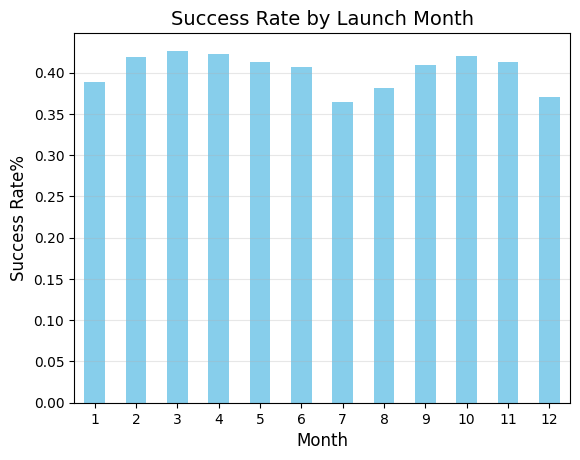

In [25]:
month_success = df.groupby('Launch_Month')['state_numeric'].mean()
month_success.plot(kind='bar', color='skyblue')
plt.title('Success Rate by Launch Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Success Rate%', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [26]:
monthly_stats = df.groupby('Launch_Month')['state_numeric'].mean().sort_values(ascending=False)

print("Success Rate by Month (Highest to Lowest):")
print(monthly_stats)

Success Rate by Month (Highest to Lowest):
Launch_Month
3     0.426626
4     0.422958
10    0.420426
2     0.418795
5     0.413366
11    0.412939
9     0.409801
6     0.406344
1     0.388334
8     0.380919
12    0.370599
7     0.364951
Name: state_numeric, dtype: float64


Best Months to Launch: The highest success rates are found in March, April, and October. These months represent the "Peak Seasons" for Kickstarter campaigns in this dataset, with a success rate of approximately 43%.

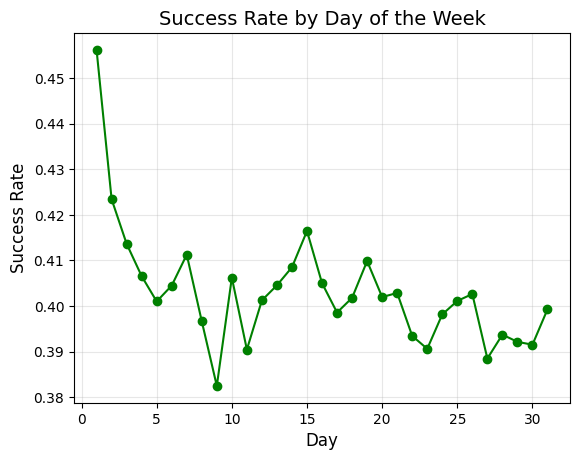

In [27]:
day_success = df.groupby('Launch_Day')['state_numeric'].mean()
day_success.plot(kind='line', marker='o', color='green')
plt.title('Success Rate by Day of the Week', fontsize=14)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Success Rate', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

Best Days to Launch: Tuesday is the top-performing day (Success Rate: 44%), followed by Wednesday. Launching in the middle of the week is more effective than weekends, as backers are more active during workdays.

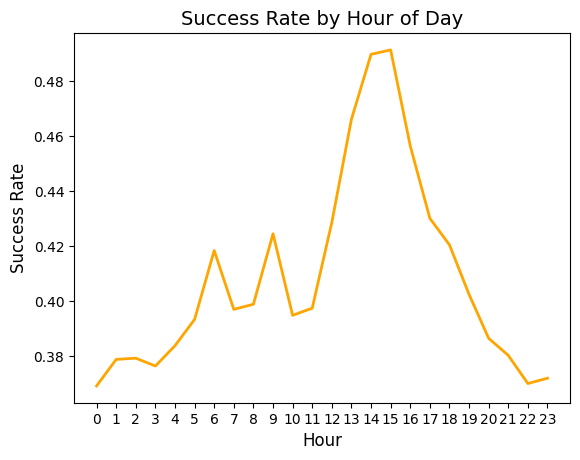

In [28]:
hour_success = df.groupby('Launch_Hour')['state_numeric'].mean()
sns.lineplot(x=hour_success.index, y=hour_success.values, color='orange', linewidth=2)
plt.title('Success Rate by Hour of Day', fontsize=14)
plt.xlabel('Hour', fontsize=12)
plt.ylabel('Success Rate', fontsize=12)
plt.xticks(range(0, 24))
plt.show()

Best Hour to Launch: The data shows that the afternoon is the "Golden Window" for launching. Specifically, 2:00 PM (Hour 14) has the highest success rate at 48%, followed closely by 1:00 PM.

In [29]:
category_success = df.groupby('Category')['state_numeric'].mean().sort_values(ascending=False)
print("Success Rate by Category:")
print(category_success)

Success Rate by Category:
Category
Dance           0.654352
Theater         0.637961
Comics          0.591415
Music           0.526299
Art             0.448908
Games           0.438920
Film & Video    0.417889
Design          0.415921
Publishing      0.347330
Photography     0.341108
Fashion         0.282846
Food            0.275914
Crafts          0.270530
Journalism      0.243973
Technology      0.237854
Name: state_numeric, dtype: float64


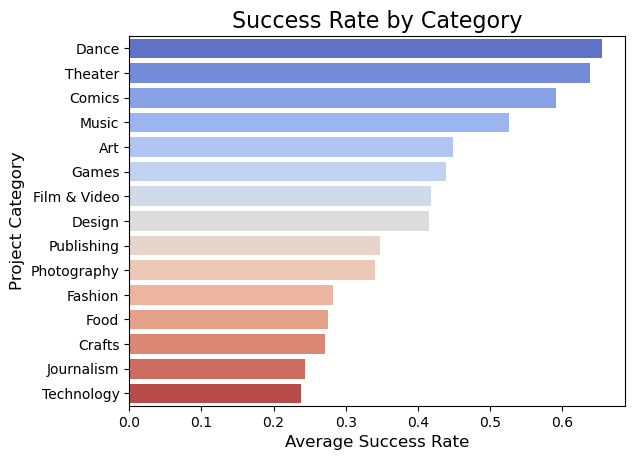

In [122]:
sns.barplot(x=category_success.values, 
            y=category_success.index, 
            hue=category_success.index, 
            palette='coolwarm', 
            legend=False)

plt.title('Success Rate by Category', fontsize=16)
plt.xlabel('Average Success Rate', fontsize=12)
plt.ylabel('Project Category', fontsize=12)
plt.show()

Top Performers: The data shows that Dance, Theater, and Comics have the highest success rates. These creative, community-focused categories consistently reach their funding goals.

Lowest Performers: Technology and Journalism projects have the lowest success rates, suggesting that these categories are more competitive or require much larger budgets that are harder to achieve.

Strategic Insight: Choosing a creative category generally leads to a higher probability of success compared to high-cost technical projects.

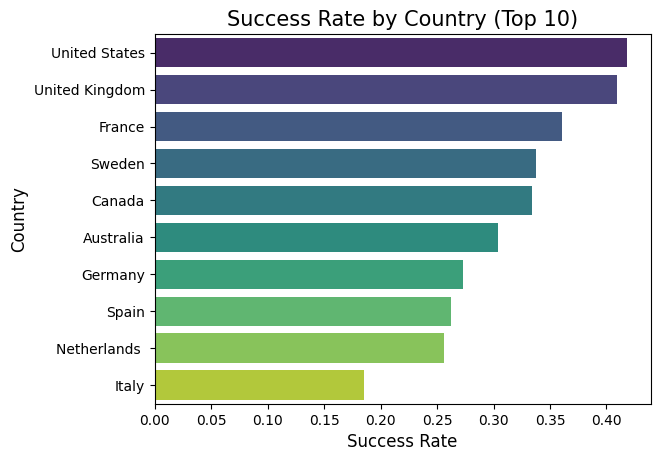

In [30]:
country_success = df.groupby('Country')['state_numeric'].mean().sort_values(ascending=False)
top_countries_list = df['Country'].value_counts().head(10).index
top_country_success = country_success.loc[top_countries_list].sort_values(ascending=False)
sns.barplot(x=top_country_success.values, y=top_country_success.index, hue=top_country_success.index, palette='viridis', legend=False)
plt.title('Success Rate by Country (Top 10)', fontsize=15)
plt.xlabel('Success Rate', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()

The United States (US) and Great Britain (GB) are not only the most frequent locations for project launches but also maintain consistently high success rates. So, Launching a project in a well-established market (like the US) provides access to a larger pool of backers, increasing the likelihood of reaching the goal.

---

## Summary


1.Financial Strategy: There is a clear negative correlation between the project goal and success. Projects with lower, more realistic goals have a much higher probability of being funded compared to those with ambitious, high-budget targets.

2. The Power of Community: The number of Backers is the strongest predictor of success (Correlation: 0.74). This proves that crowdfunding success relies on building a large community rather than seeking a few large donations.

3. Optimal Project Duration: The "Sweet Spot" for campaign length is 30 days. Shorter campaigns create a sense of urgency, while longer ones (60+ days) often suffer from a drop in momentum and backer interest.

4. The Golden Launch Window: * Best Months: Launching in March, April, or October yields the highest success rates (approx. 43%).

5. Best Day: Tuesday is the most effective day to start a campaign, capturing peak mid-week engagement.

6. Best Time: Launching in the afternoon (2:00 PM) aligns with peak activity hours for potential backers.

7. Category Performance: Creative and niche categories like Dance, Theater, and Comics consistently outperform technical or media-heavy categories like Technology and Journalism, which face much higher competition and failure rates.

8. Funding Momentum: Success on Kickstarter is often "all or nothing." Successful projects tend to gain rapid traction early on, while failed projects rarely reach even 10% of their goal, highlighting the importance of a strong first week.

9. Geographic Advantage: Projects launched in established markets like the US and UK achieve the highest success rates, benefiting from larger, more active backer communities.

## Recommendations/Conclusion

1. Optimize the Funding Goal: Set the lowest possible goal required to launch the project. Since higher goals correlate with failure, breaking a large project into smaller "phases" with lower targets can significantly increase the success rate.

2. Prioritize Community Building: Before launching, focus on gathering a following. The data proves that the number of Backers is more critical than the amount each person gives. A strong marketing push before day one is essential.

3. Perfect the Timing:
- Launch your project on a Tuesday to capture peak weekly activity.
- Aim for a mid-day launch (around 2:00 PM) to reach the widest active audience.
- Schedule the launch during high-performing months like March, April, or October to leverage seasonal spending trends.

4. Keep it Concise: Stick to a 30-day campaign duration. Longer campaigns often lose energy and fail to maintain the urgency needed to convert potential backers into supporters.

5. Strategic Categorization: If your project fits into multiple categories, choose the more creative or niche one (like Dance or Theater) over broad categories like Technology, as the competition is lower and the community engagement is higher.

5. Early Momentum is Key: The first week is a predictor of the final outcome. If a project doesn't gain traction in the first few days, consider pivoting or re-evaluating the strategy rather than extending the duration.

Conclusion:
Success on Kickstarter is not random; it is a combination of realistic financial planning, strategic timing, and category alignment. By following these data-driven recommendations, creators can significantly tilt the odds of success in their favor.